In [1]:
# Opening libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy
import PIL
import requests
import os

In [2]:
# get the path to the folder we're currently in
os.getcwd()

'/Users/mariasoto/Desktop/PhD/DSI Certificate/visualization/02_activities/assignments/Assignment-3'

In [3]:
df = pd.read_csv('opendata_2024_ontario_library_statistics.csv')
print(df.head())

         Library Full Name Library Number  Survey Year From  \
0  Addington Highlands Twp          L0005            2024.0   
1     Adjala-TosorontioTwp          L0003            2024.0   
2     Admaston/Bromley Twp          L0002            2024.0   
3                     Ajax          L0032            2024.0   
4             Alberton Twp          L1098            2024.0   

  A1.3 Ontario Library Service (OLS) Region (English)  \
0                   Southern Ontario Library Service    
1                   Southern Ontario Library Service    
2                   Southern Ontario Library Service    
3                   Southern Ontario Library Service    
4                    Ontario Library Service - North    

  A1.4 Type of Library Service (English)       A1.5 Mailing Address  \
0                Public or Union Library    3641 Flinton Rd. Box 72   
1               Contracting Municipality   7855 Sideroad 30 R.R. #1   
2                Public or Union Library         Hwy 60 P O Box 1

In [4]:
gta_cities = ["Ajax", "Aurora", "Brampton", "Brock", "Burlington", "Caledon", "Clarington", "Durham",
              "East Gwillimbury","Georgina", "Halton", "Halton Hills", "King", "Markham", "Mississauga", 
              "Milton","Newmarket", "Oakville", "Oshawa", "Pickering", "Richmond Hill", 
              "Scugog", "Toronto", "Uxbridge", "York", "Vaughan", "Whitchurch-Stouffville","Whitby"]



In [5]:
filtered_df = df[df["Library Full Name"].isin(gta_cities)]
filtered_df.sort_values(
    "P1.1  Resident Population Served",
    ascending= False
)
filtered_df = filtered_df.copy()

In [6]:
print(filtered_df.columns.values)

['Library Full Name' 'Library Number' 'Survey Year From'
 'A1.3 Ontario Library Service (OLS) Region (English)'
 'A1.4 Type of Library Service (English)' 'A1.5 Mailing Address'
 'A1.9 Street Address' 'A1.10 City/Town' 'A1.11 Province'
 'A1.12 Postal Code' 'A1.13 Web Site Address'
 'A1.14  No. of Active Library Cardholders'
 'B1.1  Net Balance brought forward from previous year'
 'B2.1.1  Public Library Operating Grant (PLOG)'
 'B2.1.2  Pay Equity Grant' 'B2.1.3  First Nation Salary Supplement Grant'
 'B2.1.4  Total Provincial Operating Funding'
 'B2.2  Local Operating Funding (e.g. Municipality or Band local operating funding)'
 'B2.3  Contract Revenue (funds from other municipalities, neighbouring public library boards, Local Services Boards or First Nation Bands that contract for library services). Specify name of contracting organization and amount received from each.'
 'B2.4.1.03  Trillium Foundation funding'
 'B2.4.1.04  Provincial student employment funding'
 'B2.4.1.05  ServiceO

In [14]:
# Turning the str type columns to numeric values so that I can get percentages
cols = ["A1.14  No. of Active Library Cardholders"]

for c in cols:
  filtered_df[c] = (
    filtered_df[c]
    .str.replace(",", "", regex=False)
    .str.strip()
    )
filtered_df[c] = pd.to_numeric(filtered_df[c], errors="coerce")


AttributeError: Can only use .str accessor with string values!

In [15]:
# Turning the str type columns to numeric values so that I can get percentages
cols = [
    "P1.1  Resident Population Served",]

for c in cols:
  filtered_df[c] = (
    filtered_df[c]
    .str.replace(",", "", regex=False)
    .str.strip()
    )
filtered_df[c] = pd.to_numeric(filtered_df[c], errors="coerce")


AttributeError: Can only use .str accessor with string values!

In [ ]:
# Checking data type
filtered_df["P1.1  Resident Population Served"].dtype

dtype('int64')

In [17]:
filtered_df["Active%"] = (
    filtered_df["A1.14  No. of Active Library Cardholders"] /
    filtered_df["P1.1  Resident Population Served"]
) * 100

In [18]:
filtered_df["Rest_of_pop"] = 100 - filtered_df["Active%"]
# Sorting the values
filtered_df = filtered_df.sort_values("Active%", ascending=True)

In [19]:
filtered_df["x_column_labels"] = (
    filtered_df["Library Full Name"] + 
    " (" +
    filtered_df["P1.1  Resident Population Served"].astype(int).map("{:,}".format) +
    ")"
)

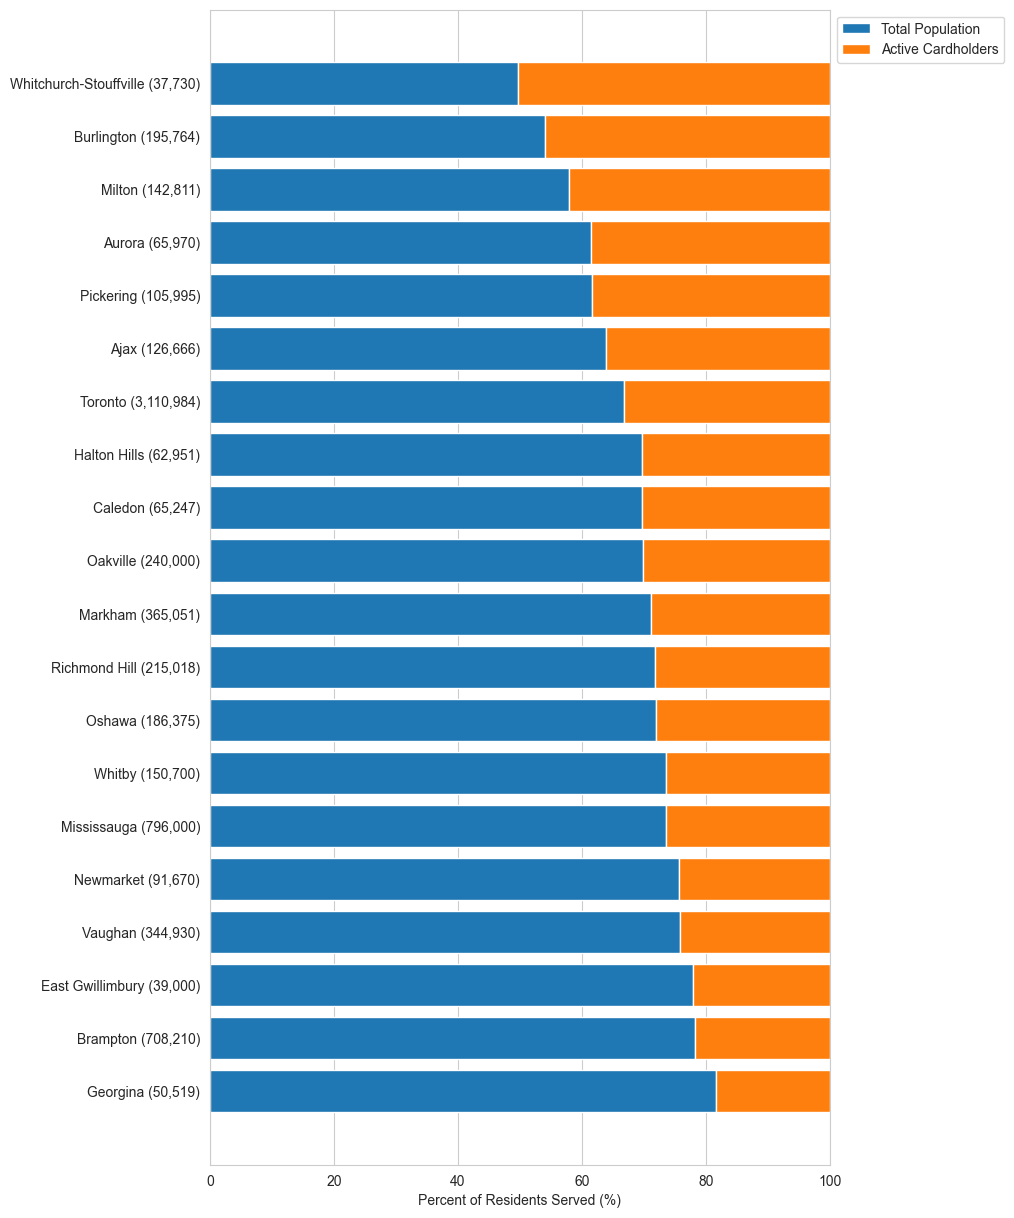

In [20]:
# Figure 1 before adjustments
plt.style.use('default')
sns.reset_orig()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(8, 15))

# Inactive portion (bottom of stack)
ax.barh(filtered_df["x_column_labels"], filtered_df["Rest_of_pop"],
    label= "Total Population"
)

# Active portion (stacked on top)
ax.barh(
    filtered_df["x_column_labels"],
    filtered_df["Active%"],
    left=filtered_df["Rest_of_pop"],
    label="Active Cardholders"
)

ax.set_xlim(0, 100)
ax.set_xlabel("Percent of Residents Served (%)")
ax.legend(loc='upper left',
bbox_to_anchor =(1, 1))

plt.show()


In [21]:
# Improving accessibility
colmap = plt.cm.viridis
colors = [colmap(0.20), colmap(0.80)]

font1 = {'family':'Arial'}

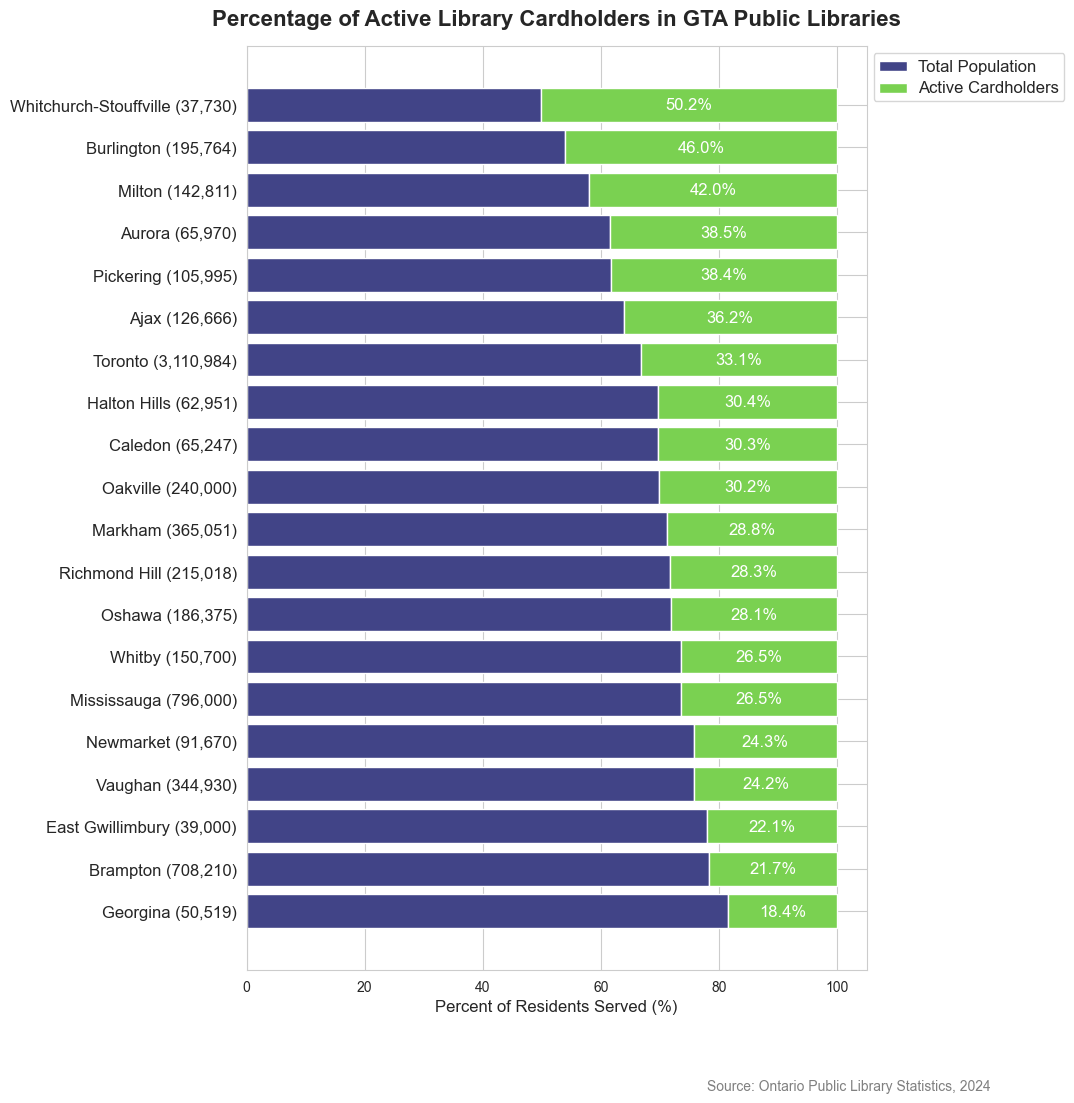

In [29]:
# Figure 1 with final edits

fig, ax = plt.subplots(figsize=(8, 12))
sns.set_style('whitegrid')
# Creating the bottom bars
ax.barh(filtered_df["x_column_labels"], filtered_df["Rest_of_pop"],
        color=colors[0],
        label= "Total Population"
)

# Adding text in the active portion to help clarity
for i, (inactive, active) in enumerate(zip(filtered_df["Rest_of_pop"], filtered_df["Active%"])):
    ax.text(
        inactive + active / 2,   # middle of the active segment
        i,                       # vertical position (library row)
        f"{active:.1f}%",        # label text
        va="center",
        ha="center",
        color="white",
        fontsize=12,
        fontname="Arial"
    )

# Adding the Active cardholders portion
ax.barh(
    filtered_df["x_column_labels"],
    filtered_df["Active%"],
    color=colors[1],
    left=filtered_df["Rest_of_pop"],
    label="Active Cardholders"
)

ax.set_title("Percentage of Active Library Cardholders in GTA Public Libraries",
    fontname="Arial",
    fontsize=16,
    pad=15,
    fontweight="bold"
)

# Adjusting visual aspects
ax.set_xlabel("Percent of Residents Served (%)", fontsize = 12, fontdict = font1)
legend = ax.legend(loc='upper left',
bbox_to_anchor =(1, 1))

for text in legend.get_texts():
    text.set_fontname("Arial")
    text.set_fontsize(12)
    
# Customizing tick labels for accessibility
for label in ax.get_yticklabels():
    label.set_fontname("Arial")
    label.set_fontsize(12)

# Adding a source note
fig.text(
    0.7, 0.01, "Source: Ontario Public Library Statistics, 2024",
    fontsize=10,
    fontname="Arial",
    color="gray"
)


# Saving the figure
plt.savefig("Library_Engagement_GTA.png", dpi=300, bbox_inches="tight")

In [ ]:
# Figure 2 : Comparing physical visits vs digital visits in GTA Public libraries

# Cleaning the relevant columns

# Turning the str type columns to numeric values so that I can get percentages
cols = [
    "G1.1.1.W  All circulation except E-books, E-audio books, music and video",
    "G1.1.2.W  All circulation for E-books, E-audio books, music and video",
    "G1.1.3.W  Total circulation of all library materials"

]
for c in cols:
    filtered_df[c] = (
        filtered_df[c]
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    filtered_df[c] = pd.to_numeric(filtered_df[c], errors="coerce")

In [31]:
# Creating variable of interest for figure

filtered_df["Non-Digital_Materials"] = (
    filtered_df["G1.1.1.W  All circulation except E-books, E-audio books, music and video"] /
    filtered_df["G1.1.3.W  Total circulation of all library materials"]
) * 100

filtered_df["Digital_Materials"] = (
    filtered_df["G1.1.2.W  All circulation for E-books, E-audio books, music and video"] /
    filtered_df["G1.1.3.W  Total circulation of all library materials"]
) * 100


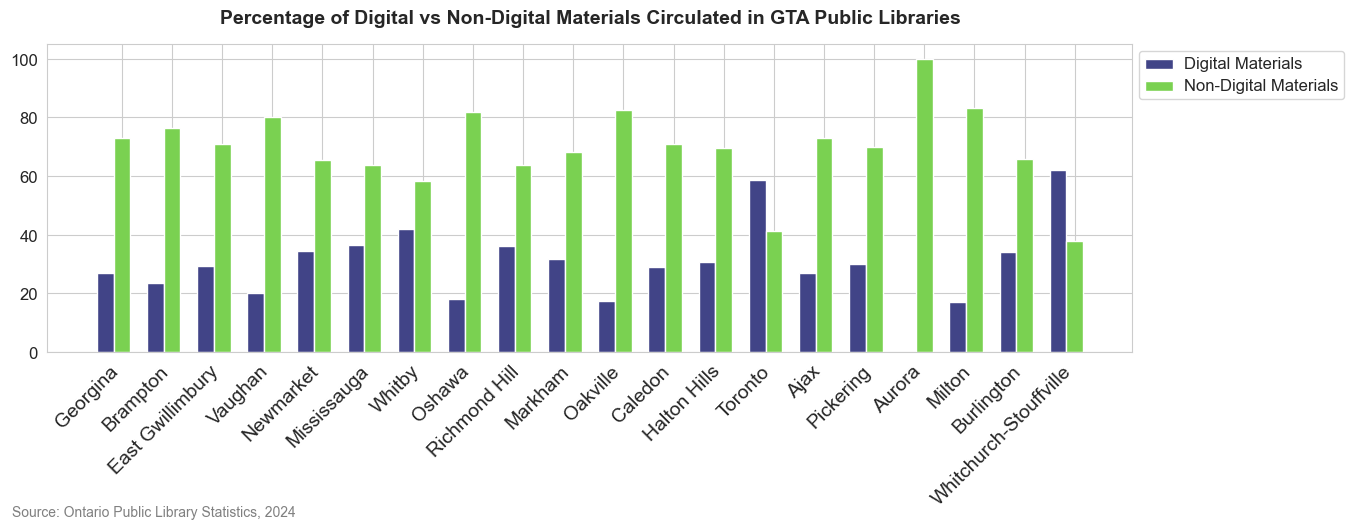

In [34]:
sns.set_style('whitegrid')

# define our figure and axes
fig, ax = plt.subplots(figsize=(14, 4))

x = np.arange(len(filtered_df)) * 1.5

# Add library names back as labels
ax.set_xticks(x+0.5)

ax.set_xticklabels(filtered_df["Library Full Name"], rotation=45, ha="right",fontsize = 14, fontdict = font1)

# Plotting desired elements
ax.bar(x , filtered_df["Digital_Materials"], width=0.5, color=colors[0], label="Digital Materials")
ax.bar(x + 0.5, filtered_df["Non-Digital_Materials"], width=0.5, color=colors[1], label="Non-Digital Materials")
legend = ax.legend( loc="lower center",
    bbox_to_anchor=(0.5, -0.45),
    ncol=2
)

ax.set_title("Percentage of Digital vs Non-Digital Materials Circulated in GTA Public Libraries",
    fontname="Arial",
    fontsize=14,
    pad=15,
    fontweight="bold"
)

fig.text(
    0.1, -0.3, "Source: Ontario Public Library Statistics, 2024",
    fontsize=10,
    fontname="Arial",
    color="gray"
)

# Adjusting visual aspects
legend = ax.legend(loc='upper left',
bbox_to_anchor =(1, 1))

for text in legend.get_texts():
    text.set_fontname("Arial")
    text.set_fontsize(12)

    

# Customizing tick labels for accessibility
for label in ax.get_yticklabels():
    label.set_fontname("Arial")
    label.set_fontsize(12)


# Saving the figure
plt.savefig("Typeof_Materials_Circulated_GTA.png", dpi=300, bbox_inches="tight")
